In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator
import numpy as np
import re
import seaborn as sns

# Gentiobiose / laminaribiose

In [2]:
def calculate_delta_i(datapath, remove_doubly_assigned = True, TSPindex = -1, baseline_error_flag = False, baseline_error = None):
    df = pd.read_excel(datapath, header=0) # Load data
    df['delta_i_not_rel'] = df['int_f'] - df['int_p'] # Calculate change in intensity
    df['delta_i'] = np.abs(df['int_f'] - df['int_p'])/np.abs(df['int_f']) # Calculate Waterlogsy factor

    # Calculate average and std
    average_w = df.groupby('Assignment')['delta_i'].mean().reset_index()
    std = df.groupby('Assignment')['delta_i'].std().reset_index()
    average_w['std'] = std['delta_i']

    if remove_doubly_assigned == True:
        average_w = average_w[~average_w['Assignment'].str.contains('-')] #remove if several assignments on one peak

    # Conditionally calculate error in delta_i
    if baseline_error_flag:
        if baseline_error is None or len(baseline_error) != 2:
            raise ValueError("baseline_error must be a tuple of two values when baseline_error_flag is True.")

        # Calculate errors
        err_f = baseline_error[0]
        err_p = baseline_error[1]
        error_delta = np.sqrt(err_f**2 + err_p**2)
        df['errors'] = np.sqrt( (error_delta/df['delta_i_not_rel'])**2 + (err_f/df['int_f'])**2 )
        
        errors = df.groupby('Assignment')['errors'].mean().reset_index()
        average_w['error'] = errors['errors'] #add errors to average_w dataframe
        return df, average_w
        
    else:
        return df, average_w

# Function to split complex assignments
def expand_avg_assignment(row):
    assignment = row['Assignment']
    delta_i = row['delta_i']
    std = row['std']  # Capture the 'std' value
    err = row['error'] # Capture the err value
    
    # Handle combined assignments
    if '-' in assignment:
        parts = assignment.split('-')
        new_assignments = []
        for part in parts:
            if 'α' in part or 'β' in part:
                new_assignments.append(part)
            else:
                # If neither alpha nor beta specified, assign both
                new_assignments.append(part + 'α')
                new_assignments.append(part + 'β')
        return [(a, delta_i, std, err) for a in set(new_assignments)]
    
    # Single assignment with α or β
    elif 'α' in assignment or 'β' in assignment:
        return [(assignment, delta_i, std, err)]
    
    # No α or β → assign to both
    else:
        return [(assignment + 'α', delta_i, std, err), (assignment + 'β', delta_i, std, err)]

# Apply expand_avg_assignment to average_delta_i dataframe
def expand_and_split(average_delta_i):
    expanded_avg = average_delta_i.apply(expand_avg_assignment, axis=1)
    expanded_flat = [item for sublist in expanded_avg for item in sublist]
    split_avg_delta = pd.DataFrame(expanded_flat, columns=['Assignment', 'delta_i', 'std', 'error'])
    split_avg_delta = split_avg_delta[~split_avg_delta['Assignment'].str.contains('TSP')]

    return split_avg_delta

# Extract base proton label (e.g., "1", "2'", "3") without α or β
def extract_base_proton(assignment):
    return re.sub(r'[αβ]', '', assignment)

# Custom sort key: numeric part, then number of apostrophes
def old_sort_key(proton):
    match = re.match(r"(\d+)(\'*)", proton)
    number = int(match.group(1))
    primes = match.group(2)
    return (number, len(primes))

def sort_key(proton):
    # Match number, optional letter, and apostrophes
    match = re.match(r"(\d+)([a-z]?)(\'*)", proton)
    if not match:
        return (float('inf'), '', 0)  # sort unknowns at the end
    
    number = int(match.group(1))
    letter = match.group(2)
    primes = match.group(3)
    return (number, letter, len(primes))

# Create new dataframe sorted by proton number
def sort_by_proton(split_avg_delta):
    # Add proton column to the DataFrame
    split_avg_delta['Proton'] = split_avg_delta['Assignment'].apply(extract_base_proton)
    
    # Sort the data
    split_avg_delta['sort_key'] = split_avg_delta['Proton'].apply(sort_key)
    split_avg_delta['type'] = split_avg_delta['Assignment'].apply(
        lambda x: 'alpha' if 'α' in x else 'beta' if 'β' in x else 'unknown'
    )
    split_avg_delta = split_avg_delta.sort_values(by='sort_key')
    return split_avg_delta

def get_plot_coordinates(df):
    protons_alpha = []
    protons_beta = []
    alpha = []
    beta = []
    alpha_err = []
    beta_err = []
    alpha_std = []
    beta_std = []
    
    #add data for alpha and beta reducing end:
    for index, row in df.iterrows():
        if row['type'] == 'alpha' and "'" not in row['Assignment']:
            alpha.append(row['delta_i'])
            alpha_std.append(row['std'])
            alpha_err.append(row['error'])
            protons_alpha.append(row['Proton'])
        elif row['type'] == 'beta' and "'" not in row['Assignment']:
            beta.append(row['delta_i'])
            beta_std.append(row['std'])
            beta_err.append(row['error'])
            protons_beta.append(row['Proton'])
    
    #add data for alpha and beta non-reducing end:
    for index, row in df.iterrows():
        if row['type'] == 'alpha' and "'" in row['Assignment']:
            alpha.append(row['delta_i'])
            alpha_err.append(row['error'])
            alpha_std.append(row['std'])
            protons_alpha.append(row['Proton'])
        elif row['type'] == 'beta' and "'" in row['Assignment']:
            beta.append(row['delta_i'])
            beta_std.append(row['std'])
            beta_err.append(row['error'])
            protons_beta.append(row['Proton'])

    return protons_alpha, protons_beta, alpha, beta, alpha_err, beta_err, alpha_std, beta_std


def get_data(datapath, baseline_error):
    int, average_delta_i = calculate_delta_i(datapath, baseline_error_flag = True, baseline_error = baseline_error)
    split_avg_delta = expand_and_split(average_delta_i)
    split_avg_delta = sort_by_proton(split_avg_delta)
    protons_alpha, protons_beta, alpha, beta, alpha_err, beta_err, alpha_std, beta_std = get_plot_coordinates(split_avg_delta)
    return protons_alpha, protons_beta, alpha, beta, alpha_err, beta_err, alpha_std, beta_std



In [3]:
# gentiobiose
datapath = "data/gentiobiose_intensities_wlogsy.xlsx"
baseline_error = [746, 946] #Calculated from standard deviation of baseline in WaterLOGSY spectra
protons_alpha_g, protons_beta_g, alpha_g, beta_g, alpha_err_g, beta_err_g, alpha_std_g, beta_std_g = get_data(datapath, baseline_error)

# laminaribiose
datapath = "data/laminaribiose_intensities_wlogsy.xlsx"
baseline_error = [507, 715]
protons_alpha_l, protons_beta_l, alpha_l, beta_l, alpha_err_l, beta_err_l, alpha_std_l, beta_std_l = get_data(datapath, baseline_error)

# Normalize data
maximum_wlogsy = max(max(beta_g), max(alpha_g), max(beta_l), max(alpha_l))

alpha_norm_g = np.array(alpha_g)/maximum_wlogsy
beta_norm_g = np.array(beta_g)/maximum_wlogsy
alpha_err_norm_g = np.array(alpha_err_g)/maximum_wlogsy
beta_err_norm_g = np.array(beta_err_g)/maximum_wlogsy
alpha_std_norm_g = np.array(alpha_std_g)/maximum_wlogsy
beta_std_norm_g = np.array(beta_std_g)/maximum_wlogsy

alpha_norm_l = np.array(alpha_l)/maximum_wlogsy
beta_norm_l = np.array(beta_l)/maximum_wlogsy
alpha_err_norm_l = np.array(alpha_err_l)/maximum_wlogsy
beta_err_norm_l = np.array(beta_err_l)/maximum_wlogsy
alpha_std_norm_l = np.array(alpha_std_l)/maximum_wlogsy
beta_std_norm_l = np.array(beta_std_l)/maximum_wlogsy

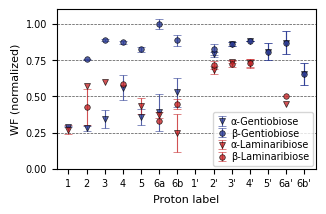

In [4]:
width_mm = 85
width_in = width_mm / 25.4  # convert mm → inches
height_in = width_in * 0.618  # golden ratio


plt.rcParams.update({
    "font.size": 8,        # base font size
    "axes.labelsize": 8,   # axis labels
    "xtick.labelsize": 7,  # x tick labels
    "ytick.labelsize": 7,  # y tick labels
    "legend.fontsize": 7,  # legend
})

# Plot error with either standard deviations of delta_i (yerr = alpha_std, beta_std), or with standard deviation of baseline (yerr = alpha_err, beta_err)
plt.figure(figsize=(width_in, height_in))

# Plot invisible data
x = ['1', '2', '3', '4', '5', '6a', '6b', "1'", "2'", "3'", "4'", "5'", "6a'", "6b'"]
y = [0.4] * 14
plt.plot(x, y, linestyle='', marker='')

# Plot gentiobiose
plt.errorbar(protons_alpha_g, alpha_norm_g, yerr = alpha_std_norm_g, fmt ='v', alpha = 0.8, color='#2a3a93', markersize = 4, mec='black', mew=0.5, capsize = 3, elinewidth = 0.8, label = "α-Gentiobiose")
plt.errorbar(protons_beta_g, beta_norm_g, yerr = beta_std_norm_g, fmt = 'o', alpha = 0.8,color='#2a3a93', markersize = 4, mec='black', mew=0.5, capsize = 3, elinewidth = 0.8, label = "β-Gentiobiose")

# Plot laminaribiose
plt.errorbar(protons_alpha_l, alpha_norm_l, yerr = alpha_std_norm_l, fmt ='v', alpha = 0.8, color='#c62729', markersize = 4, mec='black', mew=0.5, capsize = 3, elinewidth = 0.8, label = "α-Laminaribiose")
plt.errorbar(protons_beta_l, beta_norm_l, yerr = beta_std_norm_l, fmt = 'o', alpha = 0.8, color='#c62729', markersize = 4, mec='black', mew=0.5, capsize = 3, elinewidth = 0.8, label = "β-Laminaribiose")

plt.xlabel('Proton label')
plt.ylim(0,1.1)
plt.gca().yaxis.set_major_locator(MultipleLocator(0.25))  
plt.grid(axis='y', 
         linestyle='--',   # '--', '-.', ':', etc.
         linewidth=0.5,    # thinner lines
         color='black',     # any color
         alpha=0.7)        # transparency
plt.ylabel('WF (normalized)')
plt.legend(loc='lower right',
           #frameon=False,       # removes box
           handlelength=1,      # shorter legend lines
           handletextpad=0.4,   # less space between marker and text
           borderaxespad=0.3,   # less padding inside legend
           labelspacing=0.2,    # less vertical space between entries
           fontsize=7)          # smaller text

plt.savefig('figures/wlogsy_factors.png', dpi=600, bbox_inches='tight')
plt.savefig('figures/wlogsy_factors.pdf', bbox_inches='tight')
plt.savefig('figures/wlogsy_factors.svg', bbox_inches='tight')

# Glucose

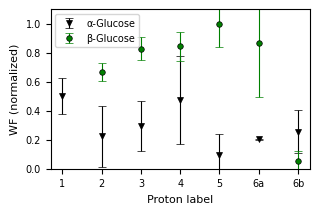

In [5]:
Glc_wlogsy = pd.read_csv("data/glc_wlogsy.txt", delimiter="\t", header=0)
Glc_wlogsy['a'] = Glc_wlogsy['a'].str.replace(',', '.').astype(float)
Glc_wlogsy['b'] = Glc_wlogsy['b'].str.replace(',', '.').astype(float)
Glc_wlogsy['a_std'] = Glc_wlogsy['a_std'].str.replace(',', '.').astype(float)
Glc_wlogsy['b_std'] = Glc_wlogsy['b_std'].str.replace(',', '.').astype(float)


protons = ['1', '2', '3', '4', '5', '6a', '6b']


width_mm = 85
width_in = width_mm / 25.4  # convert mm → inches
height_in = width_in * 0.618  # golden ratio


plt.rcParams.update({
    "font.size": 8,        # base font size
    "axes.labelsize": 8,   # axis labels
    "xtick.labelsize": 7,  # x tick labels
    "ytick.labelsize": 7,  # y tick labels
    "legend.fontsize": 7,  # legend
})



plt.figure(figsize=(width_in, height_in))
plt.errorbar(protons, Glc_wlogsy['a'], yerr = Glc_wlogsy['a_std'], fmt ='v', alpha = 1, color='k', markersize = 4, mec='black', mew=0.5, capsize = 3, elinewidth = 0.8, label="α-Glucose")
plt.errorbar(protons, Glc_wlogsy['b'], yerr = Glc_wlogsy['b_std'], fmt ='o', alpha = 1, color='green', markersize = 4, mec='black', mew=0.5, capsize = 3, elinewidth = 0.8, label="β-Glucose")

plt.xlabel('Proton label')
plt.ylabel('WF (normalized)')
plt.ylim(0, 1.1)
plt.legend(loc = 'upper left')

plt.savefig('figures/wlogsy_factors_glucose.png', dpi=600, bbox_inches='tight')
plt.savefig('figures/wlogsy_factors_glucose.pdf', bbox_inches='tight')